# Boundary Attack

This notebook demonstrates the **Boundary Attack** (Brendel, Rauber & Bethge, 2018) against three pre-trained CNNs: EfficientNetB0, InceptionV3, and MobileNetV2.

Boundary Attack is the hardest realistic black-box threat model: **decision-based**. It never sees gradients (like FGSM/PGD/C&W/DeepFool) nor even class probabilities (like Square Attack/NES), only the model's **top-1 predicted label**, exactly what a real deployed classifier typically exposes to an end user. Starting from an image that is already misclassified, it performs a random walk *along* the decision boundary, alternating a step that keeps the image adversarial with a step that shrinks its distance to the original image.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff, decode_predictions as decode_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc, decode_predictions as decode_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob, decode_predictions as decode_mob

### Setup Models and Images
We reuse the same `models_dict` / `images_dict` structure as the other white-box notebooks. Boundary Attack has no $\varepsilon$ budget to normalize: it is a pure decision-based walk that only ever asks the model for its top-1 label.

In [2]:
# Helper functions for denormalization based on model preprocessing
def denormalize_eff(img):
    # EfficientNet uses [0, 255] range
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

def denormalize_neg1_1(img):
    # MobileNetV2 and InceptionV3 use [-1, 1] range
    img = (img + 1.0) / 2.0 # Convert to [0, 1]
    img = img * 255.0 # Convert to [0, 255]
    img = tf.clip_by_value(img, 0, 255)
    return img.numpy().squeeze().astype("uint8")

# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'decode_fn': decode_mob,
        'denormalize_fn': denormalize_neg1_1,
        'clip_min': -1.0,
        'clip_max': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'decode_fn': decode_eff,
        'denormalize_fn': denormalize_eff,
        'clip_min': 0.0,
        'clip_max': 255.0
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'decode_fn': decode_inc,
        'denormalize_fn': denormalize_neg1_1,
        'clip_min': -1.0,
        'clip_max': 1.0
    }
}

# Freeze weights - black-box attacks never use gradients, but we keep this
# for consistency with the rest of the repo and to speed up inference.
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images
# Reduced to 1 image (Boundary Attack's decision-based random walk needs many
# per-query model calls; 3 models x 2 images x [50,200,500,1000] timed out twice at 5400s)
images_dict = {
    'Dog': '../../images/dog.png'
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

def get_imagenet_label(prob, decode_fn):
    return decode_fn(prob, top=1)[0][0]

def get_imagenet_class_index(prob):
    return int(tf.argmax(prob, axis=-1).numpy()[0])

def euclidean_distance(img1, img2):
    return np.linalg.norm(np.array(img1) - np.array(img2))

### Boundary Attack Algorithm
Starting from an initial adversarial point $x_{adv}^0$ (any image already misclassified relative to the original label $y$), each iteration performs two moves:
1. **Orthogonal step:** a random perturbation $\eta$, projected to be orthogonal to $x - x_{adv}$, keeping the distance to the original image roughly constant while exploring the boundary.
2. **Step towards the source:** a small move of $x_{adv}$ towards $x$, shrinking $\lVert x - x_{adv} \rVert_2$.

A candidate is only accepted if it is still misclassified, the only piece of information the attacker is allowed to observe. Over many iterations, $x_{adv}$ converges to the closest point on the decision boundary to $x$.

In [4]:
def boundary_attack(input_image, true_idx, current_model, clip_min, clip_max,
                     query_budget=1000, spherical_step=0.01, source_step=0.01, max_init_tries=1000):
    """Decision-based black-box attack (Brendel et al., 2018): walks along the decision
    boundary using only the model's top-1 predicted label, never its scores or gradients."""
    queries_used = 0

    # 1) Find any starting point that is already misclassified
    adv_image = None
    for _ in range(max_init_tries):
        candidate = tf.random.uniform(input_image.shape, minval=clip_min, maxval=clip_max)
        pred_idx = int(tf.argmax(current_model(candidate, training=False)[0]).numpy())
        queries_used += 1
        if pred_idx != true_idx:
            adv_image = candidate
            break

    if adv_image is None: # Could not find a valid starting point within the budget
        return input_image, queries_used

    # 2) Walk along the boundary: alternate an orthogonal step and a step towards the original image
    while queries_used < query_budget:
        diff = input_image - adv_image
        diff_norm = tf.norm(diff)

        # Random orthogonal perturbation, projected to remove any component along `diff`
        eta = tf.random.normal(input_image.shape)
        eta = eta - (tf.reduce_sum(eta * diff) / (diff_norm ** 2 + 1e-12)) * diff
        eta = eta / (tf.norm(eta) + 1e-12) * spherical_step * diff_norm

        candidate = tf.clip_by_value(adv_image + eta, clip_min, clip_max)
        pred_idx = int(tf.argmax(current_model(candidate, training=False)[0]).numpy())
        queries_used += 1

        if pred_idx != true_idx:
            # Orthogonal step stayed adversarial: now nudge it towards the original image
            candidate2 = tf.clip_by_value(candidate + source_step * (input_image - candidate), clip_min, clip_max)
            if queries_used < query_budget:
                pred_idx2 = int(tf.argmax(current_model(candidate2, training=False)[0]).numpy())
                queries_used += 1
                adv_image = candidate2 if pred_idx2 != true_idx else candidate
            else:
                adv_image = candidate

    return adv_image, queries_used

### Evaluation Loop
There is no $\varepsilon$ to sweep here, so instead we sweep the **query budget** directly, watching $L_2$ distance to the original image shrink (and visual quality improve) as the boundary walk is given more steps.


EXECUTING BOUNDARY ATTACKS ON MODEL: MobileNetV2

--- Target Image: Dog ---


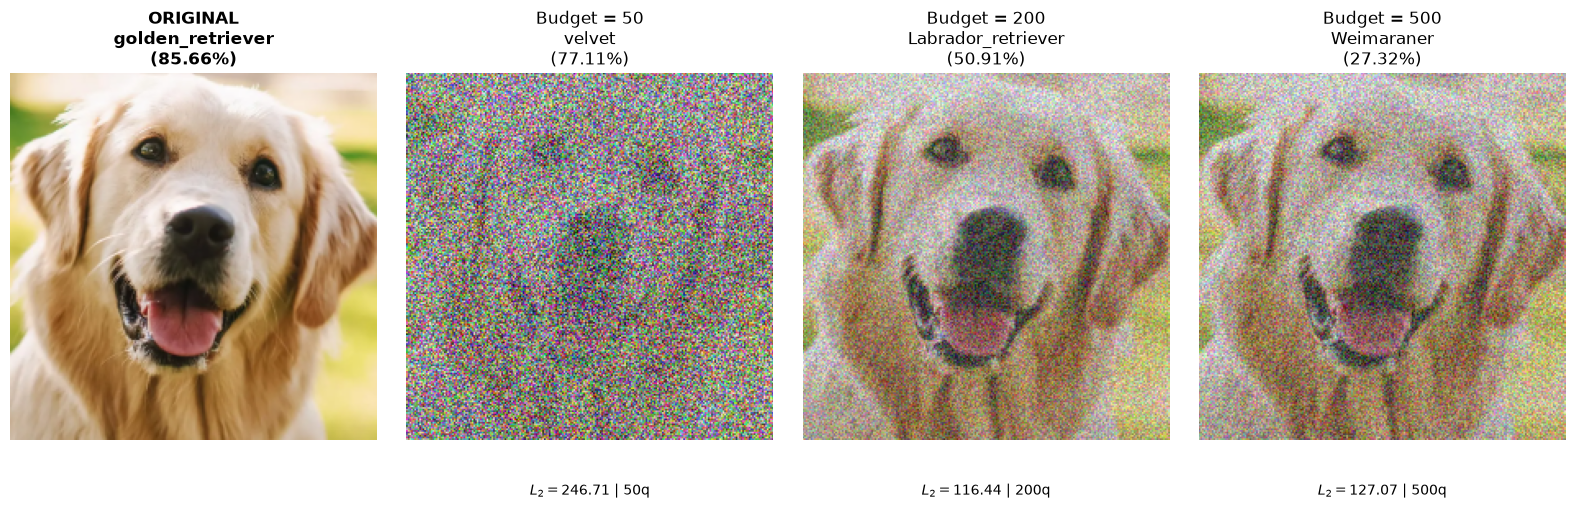


EXECUTING BOUNDARY ATTACKS ON MODEL: EfficientNetB0

--- Target Image: Dog ---


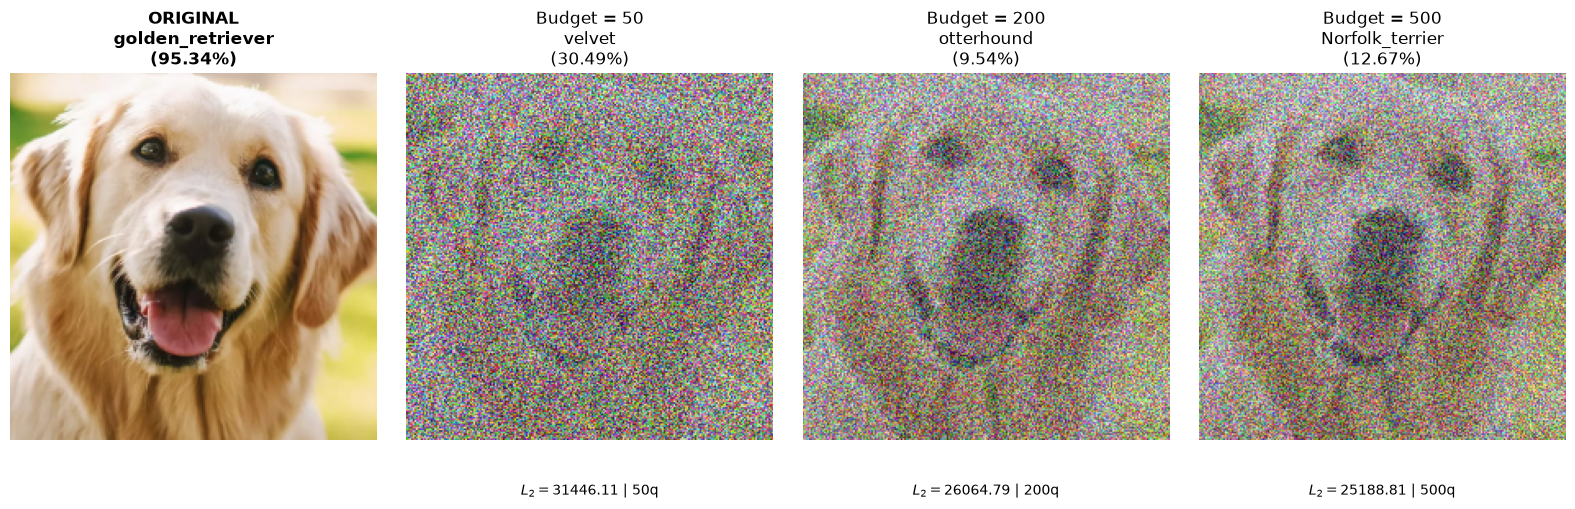


EXECUTING BOUNDARY ATTACKS ON MODEL: InceptionV3

--- Target Image: Dog ---


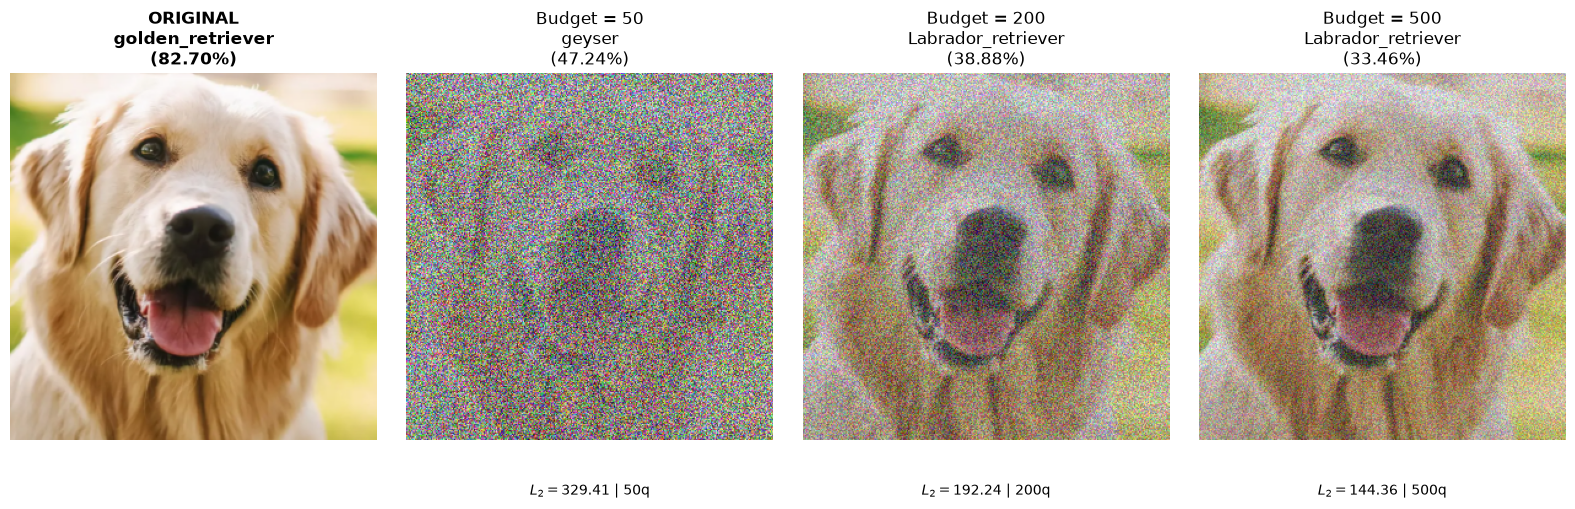

In [5]:
query_budgets = [50, 200, 500]  # dropped 1000 (same reduction pattern as 02_NES.ipynb) to fit the CPU time budget
num_cols = len(query_budgets) + 1 # +1 to include the original image as a baseline

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"EXECUTING BOUNDARY ATTACKS ON MODEL: {model_name}")
    print(f"{'='*80}\n")

    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    decode_fn = m_config['decode_fn']
    denormalize_fn = m_config['denormalize_fn'] # Dynamic denormalization function
    clip_min = m_config['clip_min']
    clip_max = m_config['clip_max']

    for img_name, img_path in images_dict.items():
        print(f"--- Target Image: {img_name} ---")

        # Create a new figure for this specific model and image
        fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4.5))
        fig.subplots_adjust(wspace=0.1)

        # Load and Preprocess
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)

        # Get Original Prediction
        original_probs = current_model.predict(input_img, verbose=0)
        _, orig_class_name, orig_prob = get_imagenet_label(original_probs, decode_fn)
        true_idx = get_imagenet_class_index(original_probs)

        # Plot Original Image in the first column
        ax_orig = axes[0]
        ax_orig.imshow(denormalize_fn(input_img)) # Apply specific denormalization
        ax_orig.set_title(f'ORIGINAL\n{orig_class_name}\n({orig_prob * 100:.2f}%)', fontweight='bold')
        ax_orig.axis('off')

        # Iterate over query budgets
        for col_idx, query_budget in enumerate(query_budgets, start=1):
            # Execute Boundary Attack
            adv_img, queries_used = boundary_attack(input_img, true_idx, current_model, clip_min, clip_max, query_budget=query_budget)

            # Calculate L2 Distance
            l2 = euclidean_distance(input_img, adv_img)

            # Get Adversarial Prediction
            adv_img_probs = current_model.predict(adv_img, verbose=0)
            _, adv_img_class, adv_class_prob = get_imagenet_label(adv_img_probs, decode_fn)

            # Plot Adversarial Image
            ax = axes[col_idx]
            ax.imshow(denormalize_fn(adv_img))
            ax.set_title(f'Budget = {query_budget}\n{adv_img_class}\n({adv_class_prob * 100:.2f}%)')
            ax.text(0.5, -0.15, f'$L_2={l2:.2f}$ | {queries_used}q', transform=ax.transAxes, ha='center', fontsize=10)
            ax.axis('off')

        plt.tight_layout()
        plt.show()